# Sequential Active Cooling Through the `|q,n_r,n_s>` Ladder

This notebook is the interactive reproducibility companion for the storage-cooling study. It follows the same state convention used in the report, `|q,n_r,n_s>`, even though the internal simulator tensor ordering is `(transmon, storage, readout)`. The notebook is load-first by default and includes commented rerun cells for the expensive calculations.

## 1. Title and Overview

This notebook reproduces the main claims of the study:
1. The dressed Step A ladder `|g,0_r,n_s> <-> |f,0_r,n_s-1>` and Step B ladder `|f,0_r,n_s-1> <-> |g,1_r,n_s-1>` are resolved through `n_s = 4`.
2. Paper-guided smooth ramps matter for Step A: the `bump` family wins for three of the four manifolds.
3. The recommended pulses show no resolved detuning shift within the `+-2 MHz` effective-model scan.
4. The full open-system primitive cools both basis states and non-Fock inputs.

## 2. Environment Setup

This cell locates the study directories, loads standard analysis libraries, and defines a few helpers for reading saved artifacts and displaying figures. It also chooses the study root robustly so the notebook can be executed from either the `scripts/` directory or the study root.

In [1]:
from __future__ import annotations

import csv
import json
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_study_dir() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / 'data').exists() and (candidate / 'figures').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise RuntimeError('Could not locate the study directory from the current working directory.')

study_dir = find_study_dir()
scripts_dir = study_dir / 'scripts'
data_dir = study_dir / 'data'
artifacts_dir = study_dir / 'artifacts'
figures_dir = study_dir / 'figures'

def read_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def read_csv(path: Path):
    with path.open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))

def show_png(stem: str, title: str | None = None, figsize=(6.5, 4.5)):
    fig, ax = plt.subplots(figsize=figsize)
    image = mpimg.imread(figures_dir / f'{stem}.png')
    ax.imshow(image)
    ax.axis('off')
    if title:
        ax.set_title(title)
    plt.show()

display(Markdown(f'Using study directory: `{study_dir}`'))

Using study directory: `C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\storage_active_cooling_gf_sideband`

## 3. User-Tunable Parameters

All adjustable knobs are collected in one place here. Re-running this cell and the next one is enough to propagate a new truncation, timestep, or calibration window into the optional rerun cells.

In [2]:
params = {
    'n_tr': 4,
    'n_storage': 7,
    'n_readout': 3,
    'default_dt_ns': 0.25,
    'ringdown_multiple': 4.0,
    'selected_n': 4,
    'detuning_scan_offsets_MHz': [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0],
    'robustness_detuning_window_MHz': 1.0,
    'robustness_amplitude_window_fraction': 0.10,
    'coherent_alpha': 1.1,
    'thermal_probs': [0.44, 0.28, 0.16, 0.08, 0.04],
    'floquet_n_tr': 6,
    'floquet_n_storage': 8,
    'floquet_n_readout': 4,
}

param_effects = {
    'n_tr': 'Baseline transmon truncation used by the study.',
    'n_storage': 'Storage cutoff used for the production run.',
    'n_readout': 'Readout cutoff used for the production run.',
    'default_dt_ns': 'Time resolution for pulse simulation.',
    'ringdown_multiple': 'Passive wait after Step B in units of 1/kappa_r.',
    'selected_n': 'Which basis-state primitive to inspect in detail.',
    'detuning_scan_offsets_MHz': 'Offsets used in the saved frequency-calibration scan.',
    'robustness_detuning_window_MHz': 'Neighborhood used for the local sensitivity summary.',
    'robustness_amplitude_window_fraction': 'Amplitude-error neighborhood used for the local sensitivity summary.',
    'coherent_alpha': 'Amplitude of the coherent-state repeated-cycle test.',
    'thermal_probs': 'Initial thermal-like storage population used in the mixed-state test.',
    'floquet_n_tr': 'Transmon cutoff used in the qualitative Floquet check.',
    'floquet_n_storage': 'Storage cutoff used in the qualitative Floquet check.',
    'floquet_n_readout': 'Readout cutoff used in the qualitative Floquet check.',
}

for key, value in params.items():
    print(f'{key:>33}: {value}')
    print(f'    effect: {param_effects[key]}')

                             n_tr: 4
    effect: Baseline transmon truncation used by the study.
                        n_storage: 7
    effect: Storage cutoff used for the production run.
                        n_readout: 3
    effect: Readout cutoff used for the production run.
                    default_dt_ns: 0.25
    effect: Time resolution for pulse simulation.
                ringdown_multiple: 4.0
    effect: Passive wait after Step B in units of 1/kappa_r.
                       selected_n: 4
    effect: Which basis-state primitive to inspect in detail.
        detuning_scan_offsets_MHz: [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
    effect: Offsets used in the saved frequency-calibration scan.
   robustness_detuning_window_MHz: 1.0
    effect: Neighborhood used for the local sensitivity summary.
robustness_amplitude_window_fraction: 0.1
    effect: Amplitude-error neighborhood used for the local sensitivity summary.
                   coherent_alpha: 1.1
    effect:

## 4. Derived Objects

This cell builds the local model, rotating frame, and noise model from the parameter cell above. It also imports the helper functions needed by the optional rerun cells.

In [3]:
import sys
sys.path.insert(0, str(scripts_dir))

from common import build_frame, build_model, build_noise

model = build_model(
    n_tr=params['n_tr'],
    n_storage=params['n_storage'],
    n_readout=params['n_readout'],
)
frame = build_frame(model)
noise = build_noise()

display(Markdown(
    f"Model dimensions: transmon={model.n_tr}, readout={model.n_readout}, storage={model.n_storage}."
))

Model dimensions: transmon=4, readout=3, storage=7.

## 5. Step-by-Step Reproduction

Each subsection below follows the same pattern: a markdown explanation, a load-saved-results cell, and a commented rerun cell.

### 5.1 Dressed Frequencies and Labels

This section reproduces the spectroscopy table that guides experiment. It shows the user-facing labels `|q,n_r,n_s>`, the Step A and Step B frequencies, and the nearest-line spacing.

n=1: |g -> 0 at |f GHz; 0 -> 1> at 0> GHz; nearest spacing = 1 MHz
n=2: |g -> 0 at |f GHz; 0 -> 2> at 1> GHz; nearest spacing = 1 MHz
n=3: |g -> 0 at |f GHz; 0 -> 3> at 2> GHz; nearest spacing = 1 MHz
n=4: |g -> 0 at |f GHz; 0 -> 4> at 3> GHz; nearest spacing = 1 MHz


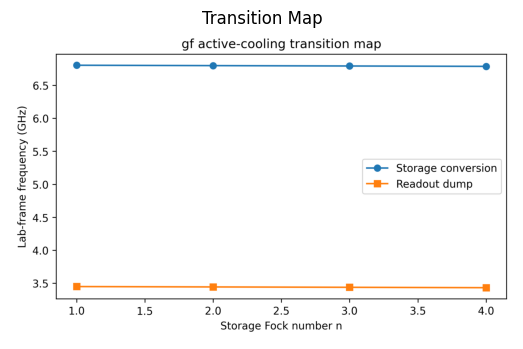

In [4]:
# --- Load saved results (default) ---
frequency_rows = read_csv(data_dir / 'frequency_table.csv')
for row in frequency_rows:
    print(
        f"n={row['n']}: {row['initial_state']} -> {row['step_a_target_state']} at {row['storage_sideband_lab_GHz']} GHz; "
        f"{row['step_a_target_state']} -> {row['step_b_target_state']} at {row['readout_dump_lab_GHz']} GHz; "
        f"nearest spacing = {row['nearest_storage_sideband_detuning_MHz']} MHz"
    )
show_png('transition_map', title='Transition Map')

In [5]:
# --- Re-run with current parameters ---
# from run_study import spectrum_and_frequency_table
# fresh_frequency_data = spectrum_and_frequency_table(model, frame)
# fresh_frequency_data['frequency_rows']

### 5.2 Pulse-Family Comparison

This section reloads the best pulse for each family and each storage manifold. It is the clearest place to see the paper-guided pulse-design outcome: `bump` wins Step A for three of the four `n_s` values.

Best Step A pulse by storage manifold:
n=1: bump, amp=12.0 MHz, dur=20.0 ns, transfer=0.996051
n=2: square, amp=6.0 MHz, dur=30.0 ns, transfer=0.999421
n=3: bump, amp=14.0 MHz, dur=10.0 ns, transfer=0.997767
n=4: bump, amp=12.0 MHz, dur=10.0 ns, transfer=0.996048

Best Step B pulse by storage manifold:
n=1: cosine_squared, amp=12.0 MHz, dur=20.0 ns, transfer=0.996051
n=2: cosine_squared, amp=12.0 MHz, dur=20.0 ns, transfer=0.996050
n=3: cosine_squared, amp=12.0 MHz, dur=20.0 ns, transfer=0.996049
n=4: cosine_squared, amp=12.0 MHz, dur=20.0 ns, transfer=0.996048


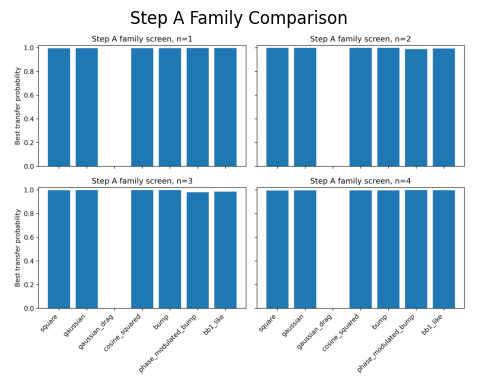

In [6]:
# --- Load saved results (default) ---
study_results = read_json(data_dir / 'study_results.json')
print('Best Step A pulse by storage manifold:')
for n in range(1, 5):
    row = study_results['best_storage'][str(n)]
    print(f"n={n}: {row['family']}, amp={row['amplitude_MHz']} MHz, dur={row['duration_ns']} ns, transfer={row['target_probability']:.6f}")
print('\nBest Step B pulse by storage manifold:')
for n in range(1, 5):
    row = study_results['best_dump'][str(n)]
    print(f"n={n}: {row['family']}, amp={row['amplitude_MHz']} MHz, dur={row['duration_ns']} ns, transfer={row['target_probability']:.6f}")
show_png('storage_family_comparison', title='Step A Family Comparison')

In [7]:
# --- Re-run with current parameters ---
# import run_study
# fresh_pulse_data = run_study.optimize_pulses(model, frame)
# fresh_pulse_data['best_storage_by_family'][str(params['selected_n'])]

### 5.3 Frequency Calibration and Floquet Check

This section reproduces the paper-motivated strong-drive diagnostics. The calibration scan checks for an effective detuning shift around each recommended pulse, and the Floquet summary checks whether the dominant target doublet follows the expected bosonic splitting.

Calibration summary:
mode=storage, n=1, family=bump, best detuning=0.0 MHz
mode=storage, n=2, family=square, best detuning=0.0 MHz
mode=storage, n=3, family=bump, best detuning=0.0 MHz
mode=storage, n=4, family=bump, best detuning=0.0 MHz
mode=readout, n=1, family=cosine_squared, best detuning=0.0 MHz
mode=readout, n=2, family=cosine_squared, best detuning=0.0 MHz
mode=readout, n=3, family=cosine_squared, best detuning=0.0 MHz
mode=readout, n=4, family=cosine_squared, best detuning=0.0 MHz

Floquet summary:
mode=storage, n=1, split=11.999174 MHz, expected=12.0 MHz, warning=Floquet modes place noticeable weight on the truncation boundary; increase the Hilbert-space dimension for quantitative strong-drive analysis.
mode=storage, n=2, split=8.485002 MHz, expected=8.485281 MHz, warning=Floquet modes place noticeable weight on the truncation boundary; increase the Hilbert-space dimension for quantitative strong-drive analysis.
mode=storage, n=3, split=24.242452 MHz, expected=24.248711 MHz, 

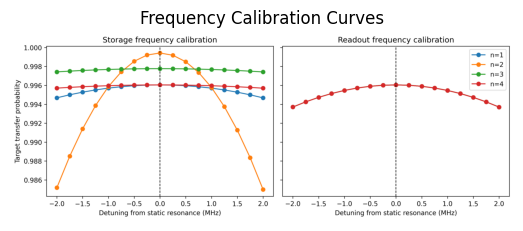

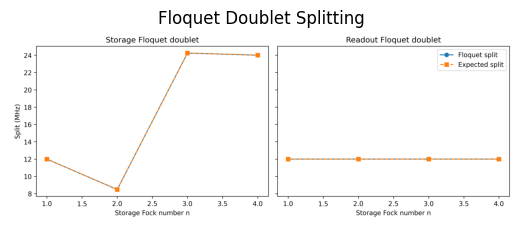

In [8]:
# --- Load saved results (default) ---
calibration_rows = study_results['frequency_calibration']
floquet_rows = study_results['floquet_summary']
print('Calibration summary:')
for row in calibration_rows:
    print(f"mode={row['mode']}, n={row['n']}, family={row['family']}, best detuning={row['optimal_detuning_MHz']} MHz")
print('\nFloquet summary:')
for row in floquet_rows:
    print(
        f"mode={row['mode']}, n={row['n']}, split={row['quasienergy_split_MHz']} MHz, "
        f"expected={row['expected_bosonic_split_MHz']} MHz, warning={row['warnings'][0]}"
    )
show_png('frequency_calibration_curves', title='Frequency Calibration Curves')
show_png('floquet_doublet_splitting', title='Floquet Doublet Splitting')

In [9]:
# --- Re-run with current parameters ---
# from run_study import calibration_frequency_scan, floquet_sideband_summary
# fresh_calibration = calibration_frequency_scan(model, frame, study_results['best_storage'], study_results['best_dump'])
# fresh_floquet = floquet_sideband_summary(study_results['best_storage'], study_results['best_dump'])
# fresh_calibration['summary'], fresh_floquet

### 5.4 Full Cooling Primitive

This section inspects one selected basis-state primitive in detail. The final metrics tell us whether the sequence cooled the storage mode, left residual transmon excitation, or stranded population in the readout.

                success_probability: 0.9620198123172237
        residual_same_n_probability: 0.0038835249189324264
               final_mean_storage_n: 2.9920590544321595
  final_transmon_excited_population: 0.004978918964963626
                    final_readout_n: 0.01761130399336569

Dominant final basis states:
  |g,0,3>: 0.962020
  |g,1,3>: 0.017403
  |g,0,2>: 0.011461
  |f,0,3>: 0.004916
  |g,0,4>: 0.003884


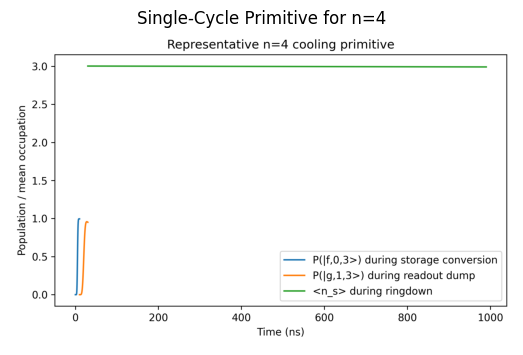

In [10]:
# --- Load saved results (default) ---
selected_n = str(params['selected_n'])
primitive = study_results['cooling_primitives'][selected_n]
for key in ['success_probability', 'residual_same_n_probability', 'final_mean_storage_n', 'final_transmon_excited_population', 'final_readout_n']:
    print(f'{key:>35}: {primitive[key]}')
print('\nDominant final basis states:')
for label, prob in primitive['final_stage_top']:
    print(f'  {label}: {prob:.6f}')
show_png('cooling_primitive_trajectories', title=f'Single-Cycle Primitive for n={selected_n}')

In [11]:
# --- Re-run with current parameters ---
# from run_study import simulate_cooling_primitive
# fresh_primitive = simulate_cooling_primitive(
#     model,
#     frame,
#     noise,
#     n=params['selected_n'],
#     best_storage_case=study_results['best_storage'][str(params['selected_n'])],
#     best_dump_case=study_results['best_dump'][str(params['selected_n'])],
# )
# fresh_primitive['success_probability']

### 5.5 Repeated-Cycle Cooling

This section reloads the repeated-cycle cooling results for a basis state, a coherent state, and a thermal-like mixture. It answers whether the protocol is genuinely useful as a cooling scheme.

Basis-state ladder:
{'final_mean_storage_n': 2.9920590544321595, 'final_readout_n': 0.01761130399336569, 'final_transmon_excited_population': 0.004978918964963626, 'target_n': 4}
{'final_mean_storage_n': 1.9990789197095298, 'final_readout_n': 0.01769930493076522, 'final_transmon_excited_population': 0.009949372741078258, 'target_n': 3}
{'final_mean_storage_n': 1.024384541245078, 'final_readout_n': 0.0174785134047756, 'final_transmon_excited_population': 0.01170601573216973, 'target_n': 2}
{'final_mean_storage_n': 0.07574084013055361, 'final_readout_n': 0.017154065732921758, 'final_transmon_excited_population': 0.009891259619728093, 'target_n': 1}

Coherent-state ladder:
{'final_mean_storage_n': 0.7598356156991453, 'final_readout_n': 0.007192838899685329, 'final_transmon_excited_population': 0.04168954377038631, 'target_n': 4}
{'final_mean_storage_n': 0.3731173922675655, 'final_readout_n': 0.007318680674831918, 'final_transmon_excited_population': 0.020640469259879474, 'target_n': 3}
{'

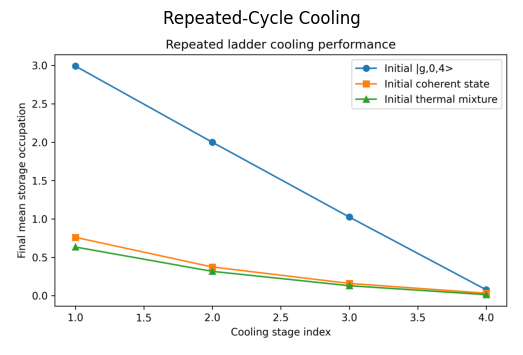

In [12]:
# --- Load saved results (default) ---
print('Basis-state ladder:')
for row in study_results['ladder_basis_g4']:
    print(row)
print('\nCoherent-state ladder:')
for row in study_results['ladder_coherent']:
    print(row)
print('\nThermal-like ladder:')
for row in study_results['ladder_thermal']:
    print(row)
show_png('cooling_per_cycle', title='Repeated-Cycle Cooling')

In [13]:
# --- Re-run with current parameters ---
# import qutip as qt
# from run_study import simulate_ladder_protocol
# initial_basis = model.basis_state(0, 4, 0)
# fresh_ladder = simulate_ladder_protocol(
#     model,
#     frame,
#     noise,
#     study_results['best_storage'],
#     study_results['best_dump'],
#     initial_basis,
# )
# fresh_ladder['cycles']

## 6. Validation

This section reloads the analytic resonance checks, the convergence pass, and the local sensitivity plot. It is the fastest way to confirm that the study is numerically stable and not just visually plausible.

Analytic resonance checks:
{'analytic_rot_MHz': -255.669695, 'difference_kHz': 0.0, 'expected_pi_ns': 20.833333, 'n': 1, 'optimized_pi_ns': 20.0, 'predicted_rot_MHz': -255.669695}
{'analytic_rot_MHz': -261.350537, 'difference_kHz': 0.0, 'expected_pi_ns': 29.462783, 'n': 2, 'optimized_pi_ns': 30.0, 'predicted_rot_MHz': -261.350537}
{'analytic_rot_MHz': -267.031379, 'difference_kHz': 0.0, 'expected_pi_ns': 10.309826, 'n': 3, 'optimized_pi_ns': 10.0, 'predicted_rot_MHz': -267.031379}
{'analytic_rot_MHz': -272.712221, 'difference_kHz': 0.0, 'expected_pi_ns': 10.416667, 'n': 4, 'optimized_pi_ns': 10.0, 'predicted_rot_MHz': -272.712221}

Convergence checks:
baseline 0.0 0.0
transmon_5 2.7862709796044882e-06 -3.4411624016961184e-06
storage_6 4.35214505623005e-06 -6.594762638201246e-07
storage_8 6.620289354497544e-07 -2.3115696263786845e-06
readout_2 4.215607418145417e-06 5.709520136232271e-06
readout_4 4.627494054265657e-05 -4.20640560649943e-06
dt_0p125 9.219313874453405e-05 -8.6419731899045

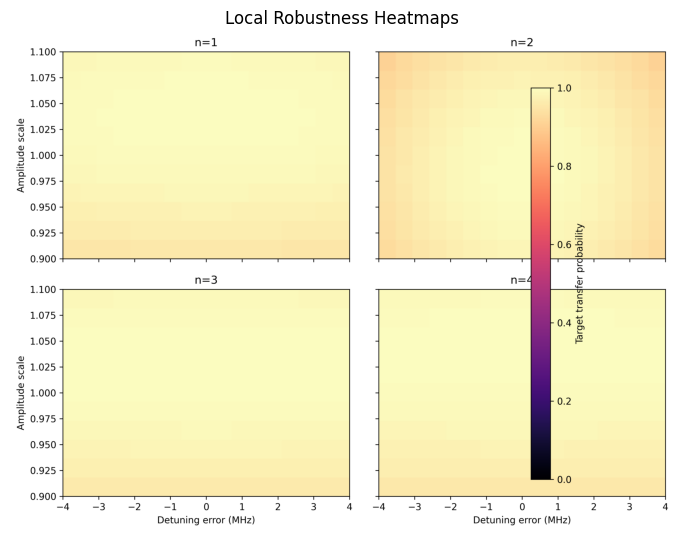

In [14]:
# --- Load saved results (default) ---
validation_rows = read_json(artifacts_dir / 'validation_summary.json')
convergence_payload = read_json(artifacts_dir / 'convergence_checks.json')
print('Analytic resonance checks:')
for row in validation_rows:
    print(row)
print('\nConvergence checks:')
for row in convergence_payload['rows']:
    print(row['label'], row['delta_success_probability'], row['delta_final_mean_storage_n'])
show_png('sensitivity_heatmaps', title='Local Robustness Heatmaps', figsize=(9, 6.5))

In [15]:
# --- Re-run with current parameters ---
# from run_study import validation_summary
# fresh_validation = validation_summary(model, frame, study_results['best_storage'])
# fresh_validation

## 7. Key Figures

These cells re-display the main figures used in the report so the study can be skimmed quickly from the notebook.

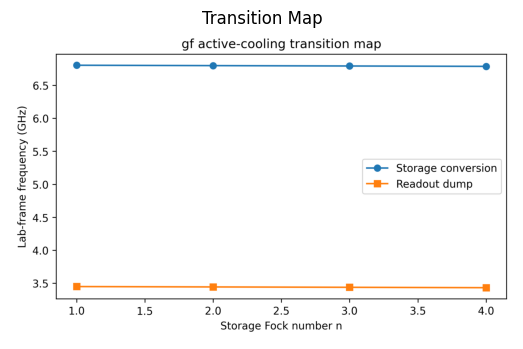

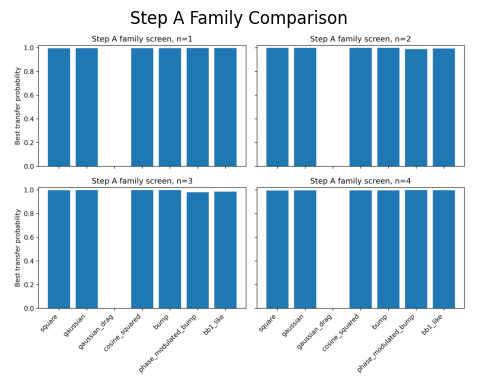

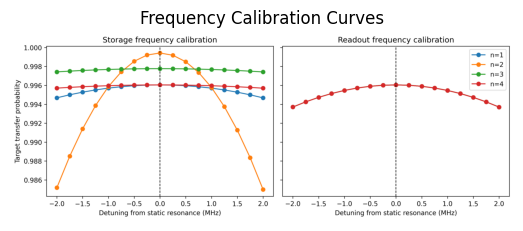

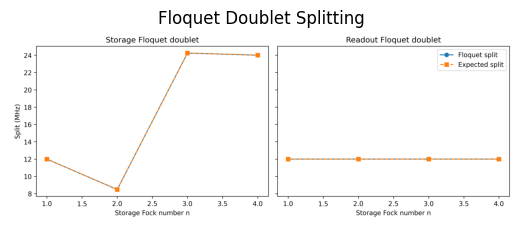

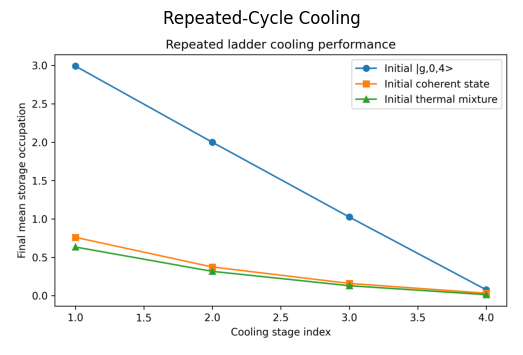

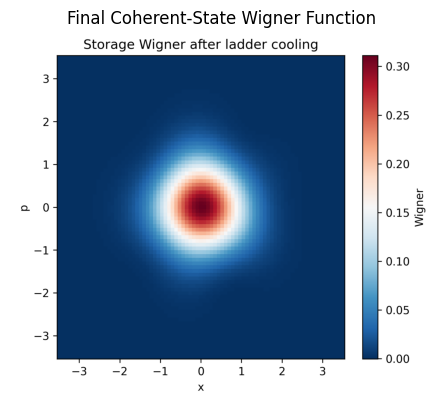

In [16]:
show_png('transition_map', title='Transition Map')
show_png('storage_family_comparison', title='Step A Family Comparison')
show_png('frequency_calibration_curves', title='Frequency Calibration Curves')
show_png('floquet_doublet_splitting', title='Floquet Doublet Splitting')
show_png('cooling_per_cycle', title='Repeated-Cycle Cooling')
show_png('coherent_final_wigner', title='Final Coherent-State Wigner Function', figsize=(5.5, 4.8))

## 8. Summary

The notebook reproduces the main conclusions of the study from the saved artifacts. The protocol is viable in the effective model through `n_s = 4`, the `bump` family is the best Step A choice for most manifolds, the Step B dump is best served by a cosine-squared pulse, and repeated application cools the storage mode strongly for both basis and non-Fock inputs.

In [17]:
summary_rows = [
    ('step A n=1 frequency (GHz)', frequency_rows[0]['storage_sideband_lab_GHz']),
    ('step A n=4 frequency (GHz)', frequency_rows[3]['storage_sideband_lab_GHz']),
    ('best step A family at n=4', study_results['best_storage']['4']['family']),
    ('single-cycle n=4 success', study_results['cooling_primitives']['4']['success_probability']),
    ('basis ladder final mean n', study_results['ladder_basis_g4'][-1]['final_mean_storage_n']),
    ('coherent ladder final mean n', study_results['ladder_coherent'][-1]['final_mean_storage_n']),
    ('thermal ladder final mean n', study_results['ladder_thermal'][-1]['final_mean_storage_n']),
]
for label, value in summary_rows:
    print(f'{label:>34}: {value}')

        step A n=1 frequency (GHz): |f
        step A n=4 frequency (GHz): |f
         best step A family at n=4: bump
          single-cycle n=4 success: 0.9620198123172237
         basis ladder final mean n: 0.07574084013055361
      coherent ladder final mean n: 0.03128518703888277
       thermal ladder final mean n: 0.0125082027468783
